# KIARA — RAAE Preprocessing Pipeline
### Retina Anatomy-Aware Enhancement for Diabetic Retinopathy Severity Grading

**Project:** KIARA (Knowledge-based Intelligent Analysis for Retinal Assessment)
**This notebook:** RAAE preprocessing ONLY — no model, no training.
**Downstream notebook:** `Swin_RAAE_Training.ipynb` (consumes the images this notebook produces)

---

#### What is KIARA?
KIARA is a Diabetic Retinopathy (DR) severity grading system that classifies retinal
fundus images from the APTOS 2019 dataset into 5 clinical severity grades:

| Grade | Class |
|---|---|
| 0 | No DR |
| 1 | Mild |
| 2 | Moderate |
| 3 | Severe |
| 4 | Proliferative DR |

#### What is RAAE?
**Retina Anatomy-Aware Enhancement (RAAE)** is a domain-specific image preprocessing
pipeline designed specifically for fundus photography, applied *before* any deep
learning model sees the image. Unlike generic augmentation, every stage of RAAE is
motivated by retinal anatomy and DR pathology:

1. **Retina detection & crop** — removes the black non-anatomical camera border.
2. **Square padding** — prevents anisotropic stretching of vessel/lesion geometry on resize.
3. **Illumination correction** — removes the smooth radial flash-photography brightness
   gradient without touching fine anatomical detail.
4. **CLAHE (LAB, L-channel only)** — boosts local contrast for early-stage microaneurysm /
   hemorrhage visibility while preserving the color cues used to distinguish lesion types.
5. **Edge-preserving denoising** — removes sensor/compression noise without blurring
   diagnostically-important vessel and lesion boundaries.
6. **Anatomy-aware Frangi vessel enhancement** — boosts vascular structure (a key DR severity
   signal: venous beading, IRMA, neovascularization) while *damping* the enhancement near the
   optic disc and macula so normal anatomy is not over-sharpened into a false lesion-like
   appearance. **Optic disc and macula localization are the core novelty of RAAE** and are
   deliberately preserved in this notebook.
7. **Adaptive gamma correction** — normalizes perceptual brightness across heterogeneous
   camera/exposure conditions.
8. **Resize + normalization** — final isotropic resize to the model's input resolution.

#### Why preprocess separately from training?
Precomputing and caching RAAE-enhanced images to disk (rather than applying RAAE on-the-fly
inside a PyTorch `Dataset.__getitem__`) removes the CPU-bound OpenCV/scikit-image cost from
the training loop entirely, so every subsequent training run (or hyperparameter sweep) on
`Swin_RAAE_Training.ipynb` reads pre-enhanced PNGs directly.

#### Pipeline overview

```
APTOS raw images
       │
       ▼
RAAE preprocessing pipeline   (this notebook)
       │
       ▼
Enhanced retinal images saved to disk
   /kaggle/working/RAAE_train_images
   /kaggle/working/RAAE_valid_images
       │
       ▼
Swin_RAAE_Training.ipynb   (model training — NOT in this notebook)
```


In [ ]:
!pip install -q opencv-python==4.10.0.84
!pip install -q scikit-image==0.24.0
!pip install -q numpy
!pip install -q pandas
!pip install -q matplotlib
!pip install -q Pillow
!pip install -q tqdm

print("Preprocessing dependencies installed successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 MB 29.3 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 91.6 MB/s eta 0:00:00:00:01:01


In [1]:
import os
from pathlib import Path

import cv2
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from PIL import Image

from skimage.filters import frangi
from skimage import img_as_ubyte

from tqdm import tqdm

print("Imports OK — preprocessing-only environment (no torch / no timm).")

Imports OK — preprocessing-only environment (no torch / no timm).


In [2]:
# ------------------------------------------------------------------
# Raw APTOS 2019 input directories
# ------------------------------------------------------------------
DATA_DIR = "/kaggle/input/datasets/mariaherrerot/aptos2019"

TRAIN_IMG_DIR = os.path.join(DATA_DIR, "train_images", "train_images")
VALID_IMG_DIR = os.path.join(DATA_DIR, "val_images", "val_images")

# ------------------------------------------------------------------
# RAAE-enhanced output directories (consumed later by Swin_RAAE_Training.ipynb)
# ------------------------------------------------------------------
RAAE_TRAIN_OUTPUT_DIR = "/kaggle/working/RAAE_train_images"
RAAE_VALID_OUTPUT_DIR = "/kaggle/working/RAAE_valid_images"

os.makedirs(RAAE_TRAIN_OUTPUT_DIR, exist_ok=True)
os.makedirs(RAAE_VALID_OUTPUT_DIR, exist_ok=True)

# Target resolution RAAE resizes its final output to (matches the Swin model's input size)
TARGET_SIZE = 224

print("TRAIN_IMG_DIR       :", TRAIN_IMG_DIR)
print("VALID_IMG_DIR        :", VALID_IMG_DIR)
print("RAAE_TRAIN_OUTPUT_DIR:", RAAE_TRAIN_OUTPUT_DIR)
print("RAAE_VALID_OUTPUT_DIR:", RAAE_VALID_OUTPUT_DIR)
print("TARGET_SIZE          :", TARGET_SIZE)

TRAIN_IMG_DIR       : /kaggle/input/datasets/mariaherrerot/aptos2019/train_images/train_images
VALID_IMG_DIR        : /kaggle/input/datasets/mariaherrerot/aptos2019/val_images/val_images
RAAE_TRAIN_OUTPUT_DIR: /kaggle/working/RAAE_train_images
RAAE_VALID_OUTPUT_DIR: /kaggle/working/RAAE_valid_images
TARGET_SIZE          : 224


In [3]:
def detect_and_crop_retina(image_bgr, threshold=10, pad=2):
    """
    Detects the circular retinal field-of-view and crops to its bounding box.

    Medical rationale
    ------------------
    Removes the non-anatomical black camera border so that (a) downstream contrast/illumination
    statistics are computed only over real tissue, and (b) transformer patch tokens are not
    wasted on background.

    Parameters
    ----------
    image_bgr : np.ndarray (H, W, 3), uint8, BGR (OpenCV convention)
    threshold : int, intensity below which a pixel is considered 'background'
    pad       : int, safety pixels kept around the detected bounding box

    Returns
    -------
    cropped_bgr : np.ndarray, the retina-only crop
    bbox        : (x, y, w, h) used, for traceability / logging
    """
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

    # Binary foreground mask: retina is brighter than the black surrounding border
    _, mask = cv2.threshold(gray, threshold, 255, cv2.THRESH_BINARY)

    # Morphological closing to fill small dark gaps caused by low-contrast retinal periphery
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        # Nothing detected (rare edge case) -> return original image unchanged
        h, w = gray.shape
        return image_bgr, (0, 0, w, h)

    largest_contour = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest_contour)

    H, W = gray.shape
    x0, y0 = max(x - pad, 0), max(y - pad, 0)
    x1, y1 = min(x + w + pad, W), min(y + h + pad, H)

    cropped_bgr = image_bgr[y0:y1, x0:x1]
    return cropped_bgr, (x0, y0, x1 - x0, y1 - y0)


def square_pad(image_bgr, fill_value=0):
    """
    Pads the cropped retina to a square canvas (centered) so that the subsequent resize to
    TARGET_SIZE does not anisotropically stretch the retina (which would distort vessel
    curvature and lesion geometry).
    """
    h, w = image_bgr.shape[:2]
    size = max(h, w)
    top = (size - h) // 2
    bottom = size - h - top
    left = (size - w) // 2
    right = size - w - left
    return cv2.copyMakeBorder(image_bgr, top, bottom, left, right,
                               cv2.BORDER_CONSTANT, value=[fill_value] * 3)

In [4]:
def early_resize(image_bgr, target_size=None):
    """
    OPTIMIZATION: resize the (already square) retina crop down to target_size x target_size
    immediately, so illumination correction / CLAHE / denoising / Frangi vessel enhancement
    all operate on a small, fixed-size image instead of the original full-resolution fundus
    photo (which can be 2000px+ per side in APTOS).

    This is purely a compute optimization -- it does not change the RAAE stage order or
    remove any anatomy-aware step. Frangi vesselness in particular is O(pixels), so running
    it at 224x224 instead of, e.g., 2000x2000 is roughly an 80x reduction in filtered pixels.
    """
    target_size = target_size or TARGET_SIZE
    return cv2.resize(image_bgr, (target_size, target_size), interpolation=cv2.INTER_AREA)

In [5]:
def correct_illumination(image_bgr, kernel_frac=0.08):
    """
    Removes uneven illumination while preserving fine anatomical detail.

    Medical rationale
    ------------------
    Fundus images exhibit a smooth radial brightness gradient from flash photography.
    This is not anatomical signal and, if left uncorrected, suppresses lesion visibility
    in darker peripheral regions and introduces cross-image intensity variance unrelated
    to disease state.

    Anatomy-preservation rationale
    -------------------------------
    The illumination map is estimated at a spatial scale far coarser than any vessel or
    lesion (large Gaussian kernel), so fine structures are not captured by the estimate
    and are therefore not attenuated by the correction.
    """
    img = image_bgr.astype(np.float32)
    h, w = img.shape[:2]

    ksize = int(max(h, w) * kernel_frac)
    ksize = ksize + 1 if ksize % 2 == 0 else ksize  # Gaussian kernel must be odd
    ksize = max(ksize, 31)

    corrected = np.zeros_like(img)
    for c in range(3):
        channel = img[:, :, c]
        illumination = cv2.GaussianBlur(channel, (ksize, ksize), 0)
        illumination = np.clip(illumination, 1, 255)  # avoid division by zero
        mean_val = np.mean(channel[channel > 5]) if np.any(channel > 5) else np.mean(channel)
        corrected[:, :, c] = (channel / illumination) * mean_val

    corrected = np.clip(corrected, 0, 255).astype(np.uint8)
    return corrected

In [6]:
def apply_clahe_lab(image_bgr, clip_limit=2.5, tile_grid_size=(8, 8)):
    """
    Applies CLAHE to the L-channel of the LAB color space only.

    Medical rationale
    ------------------
    Boosts local contrast so subtle microaneurysms / hemorrhages become visible against
    the retinal background, which is critical for early-stage (Grade 1) DR detection.

    Anatomy-preservation rationale
    -------------------------------
    Operating only on L (lightness) leaves the A/B chrominance channels untouched, preserving
    the red-vs-yellow color cue clinicians use to differentiate hemorrhages/microaneurysms
    from exudates/cotton-wool spots.
    """
    lab = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2LAB)
    l_channel, a_channel, b_channel = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    l_enhanced = clahe.apply(l_channel)

    lab_enhanced = cv2.merge((l_enhanced, a_channel, b_channel))
    result_bgr = cv2.cvtColor(lab_enhanced, cv2.COLOR_LAB2BGR)
    return result_bgr

In [7]:
def denoise_preserve_edges(image_bgr, d=7, sigma_color=50, sigma_space=50):
    """
    Edge-preserving denoising via bilateral filtering.

    Medical rationale
    ------------------
    Removes sensor/compression noise that could be mistaken for microaneurysms while keeping
    lesion and vessel boundaries sharp -- both are diagnostically load-bearing edges.

    Anatomy-preservation rationale
    -------------------------------
    Bilateral filtering only averages spatially-close, intensity-similar pixels, so it does not
    blur across high-contrast vessel/background or lesion/background boundaries.
    """
    return cv2.bilateralFilter(image_bgr, d=d, sigmaColor=sigma_color, sigmaSpace=sigma_space)

In [8]:
def enhance_vessels_frangi(image_bgr, scale_range=(1, 4), scale_step=1, blend_alpha=0.35):
    """
    Enhances retinal blood vessels using a multi-scale Frangi vesselness filter on the
    green channel, then soft-blends the response back into the image.

    Medical rationale
    ------------------
    Vascular abnormalities (venous beading, IRMA, neovascularization) are key DR severity
    indicators. Enhancing vessel contrast helps the downstream Swin model attend to vascular
    structure more reliably.

    Anatomy-preservation rationale
    -------------------------------
    Frangi's tubularity response is near-zero on blob-shaped structures (hemorrhages, exudates),
    so it selectively boosts vessels without artificially amplifying lesions. We blend (not
    replace) the response, so background/lesion tissue intensities are preserved.
    """
    green = image_bgr[:, :, 1].astype(np.float64) / 255.0

    # Frangi expects a float image; dark vessels on bright background -> invert so vessels are
    # 'ridges' (bright) for the filter, matching its ridge-detection assumption.
    inverted_green = 1.0 - green

    vesselness = frangi(
        inverted_green,
        sigmas=range(scale_range[0], scale_range[1] + 1, scale_step),
        black_ridges=False
    )

    # Normalize response to [0, 1]
    if vesselness.max() > vesselness.min():
        vesselness_norm = (vesselness - vesselness.min()) / (vesselness.max() - vesselness.min())
    else:
        vesselness_norm = vesselness

    vessel_map_uint8 = img_as_ubyte(vesselness_norm)

    # Blend vesselness map (as a grayscale enhancement) back into each color channel
    result = image_bgr.copy().astype(np.float32)
    vessel_3ch = cv2.cvtColor(vessel_map_uint8, cv2.COLOR_GRAY2BGR).astype(np.float32)

    result = cv2.addWeighted(result, 1.0, vessel_3ch, blend_alpha, 0)
    result = np.clip(result, 0, 255).astype(np.uint8)

    return result, vessel_map_uint8

In [9]:
def locate_optic_disc(image_bgr, brightness_percentile=95):
    """
    Heuristic, mask-free optic disc localization.
    Returns (cx, cy, radius_estimate) or None if not confidently found.
    """
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    thresh_val = np.percentile(gray, brightness_percentile)
    bright_mask = (gray >= thresh_val).astype(np.uint8) * 255

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
    bright_mask = cv2.morphologyEx(bright_mask, cv2.MORPH_OPEN, kernel)

    contours, _ = cv2.findContours(bright_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None

    largest = max(contours, key=cv2.contourArea)
    if cv2.contourArea(largest) < 30:  # too small to be a confident disc detection
        return None

    (x, y), radius = cv2.minEnclosingCircle(largest)
    return int(x), int(y), int(radius)


def estimate_macula_location(disc_center, disc_radius, image_shape, direction=-1):
    """
    Estimates macula location using the clinical geometric prior: ~2.5 disc-diameters
    temporal to the optic disc, vertically level with it.

    `direction` = -1 or +1 controls which side of the disc the macula is placed on
    (varies by left/right eye acquisition; default assumes macula is nasal-negative direction,
    i.e. offset toward image center). For batch use without laterality metadata, we default to
    offsetting toward the image horizontal center, which is correct in the majority of
    centered fundus captures.
    """
    h, w = image_shape[:2]
    cx, cy = disc_center
    disc_diameter = disc_radius * 2

    # Offset toward image center (heuristic default, avoids needing eye-laterality metadata)
    direction = -1 if cx > w / 2 else 1
    macula_x = int(cx + direction * 2.5 * disc_diameter)
    macula_y = cy

    macula_x = np.clip(macula_x, 0, w - 1)
    macula_y = np.clip(macula_y, 0, h - 1)
    return macula_x, macula_y


def build_protection_mask(image_shape, centers_radii, sigma_scale=1.5):
    """
    Builds a soft [0, 1] Gaussian mask that is HIGH (near 1) at protected anatomical centers
    (optic disc, macula) and LOW (near 0) elsewhere. Used to gently damp vessel-enhancement
    blend strength at these locations.
    """
    h, w = image_shape[:2]
    protection = np.zeros((h, w), dtype=np.float32)

    for (cx, cy, r) in centers_radii:
        yy, xx = np.mgrid[0:h, 0:w]
        sigma = max(r * sigma_scale, 10)
        gauss = np.exp(-(((xx - cx) ** 2 + (yy - cy) ** 2) / (2 * sigma ** 2)))
        protection = np.maximum(protection, gauss)

    return protection  # values in [0, 1]


def enhance_vessels_frangi_anatomy_aware(image_bgr, scale_range=(1, 4), scale_step=1,
                                          base_alpha=0.35, protect_disc_macula=True):
    """
    Anatomy-aware variant of the vessel enhancement above: locates the optic disc (and
    estimates the macula) and reduces the vessel-blend weight in those regions so that
    normal anatomy is not over-sharpened.
    """
    result_uniform, vessel_map = enhance_vessels_frangi(image_bgr, scale_range, scale_step, base_alpha)

    if not protect_disc_macula:
        return result_uniform, vessel_map, None

    disc = locate_optic_disc(image_bgr)
    if disc is None:
        return result_uniform, vessel_map, None

    dcx, dcy, dr = disc
    mx, my = estimate_macula_location((dcx, dcy), dr, image_bgr.shape)

    protection = build_protection_mask(
        image_bgr.shape, [(dcx, dcy, dr), (mx, my, max(dr // 2, 15))]
    )

    # Locally reduce blend weight where protection is high: effective_alpha = base_alpha * (1 - protection)
    alpha_map = base_alpha * (1.0 - 0.85 * protection)  # never fully zero, just heavily damped
    alpha_map_3ch = np.repeat(alpha_map[:, :, None], 3, axis=2)

    original_f = image_bgr.astype(np.float32)
    vessel_3ch = cv2.cvtColor(vessel_map, cv2.COLOR_GRAY2BGR).astype(np.float32)

    blended = original_f + alpha_map_3ch * vessel_3ch
    blended = np.clip(blended, 0, 255).astype(np.uint8)

    landmarks = {"optic_disc": (dcx, dcy, dr), "macula_estimate": (mx, my)}
    return blended, vessel_map, landmarks

In [10]:
def adaptive_gamma_correction(image_bgr, target_mean=128.0):
    """
    Applies per-image adaptive gamma correction based on current mean luminance.

    Medical rationale
    ------------------
    Normalizes perceptual brightness across images from heterogeneous cameras/exposures so
    dark lesions (hemorrhages) are not lost in under-exposed captures, without needing a
    dataset-wide fixed gamma constant.

    Anatomy-preservation rationale
    -------------------------------
    Gamma is a monotonic pixel-wise remap: relative brightness ordering (and hence
    lesion/vessel-vs-background contrast direction) is always preserved.
    """
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    current_mean = np.mean(gray)
    current_mean = max(current_mean, 1e-3)  # numerical safety

    gamma = np.log(target_mean / 255.0 + 1e-6) / np.log(current_mean / 255.0 + 1e-6)
    gamma = np.clip(gamma, 0.4, 2.5)  # keep within a perceptually sane range

    normalized = image_bgr.astype(np.float32) / 255.0
    corrected = np.power(normalized, gamma)
    corrected = np.clip(corrected * 255.0, 0, 255).astype(np.uint8)

    return corrected, gamma

In [11]:
# RAAE's own internal ImageNet-style normalization constants, kept separate from any
# training-side transform constants so this notebook has zero coupling to the training notebook.
RAAE_IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
RAAE_IMAGENET_STD = np.array([0.229, 0.224, 0.225])


def resize_and_normalize(image_bgr, target_size=None, return_tensor_stats=True):
    """
    Final RAAE stage: isotropic resize to target_size x target_size, BGR->RGB, and
    (optionally) ImageNet-style standardization for direct inspection.

    Because the pipeline already downsized to target_size right after cropping (Section 5.2,
    the optimization step), this resize is effectively a no-op / safety guarantee that the
    output is exactly target_size x target_size regardless of upstream rounding -- it is kept
    as an explicit stage for clarity and so the function remains usable standalone.

    Returns
    -------
    display_rgb : uint8 RGB image, resized -- this is the array saved to disk
    normalized  : float32 array, ImageNet-standardized (only if return_tensor_stats=True;
                  exposed for inspection/debugging only, not used by this notebook)
    """
    target_size = target_size or TARGET_SIZE
    resized_bgr = cv2.resize(image_bgr, (target_size, target_size), interpolation=cv2.INTER_AREA)
    display_rgb = cv2.cvtColor(resized_bgr, cv2.COLOR_BGR2RGB)

    normalized = None
    if return_tensor_stats:
        float_img = display_rgb.astype(np.float32) / 255.0
        normalized = (float_img - RAAE_IMAGENET_MEAN) / RAAE_IMAGENET_STD

    return display_rgb, normalized

In [12]:
def raae_pipeline(image_bgr, target_size=None, protect_disc_macula=True, verbose=False):
    """
    Full Retina Anatomy-Aware Enhancement (RAAE) pipeline -- optimized version.

    Stages
    ------
    1. Circular retina detection & crop
    2. Square padding
    3. EARLY RESIZE to target_size (optimization -- everything below now runs on a small,
       fixed-size image instead of the full-resolution original)
    4. Illumination correction
    5. CLAHE (LAB, L-channel)
    6. Edge-preserving denoising
    7. Anatomy-aware Frangi vessel enhancement (optic disc / macula protected)
    8. Adaptive gamma correction
    9. Resize + normalization (safety no-op given step 3, kept for interface clarity)

    Returns a dict of every intermediate stage (uint8, BGR unless noted) plus the final
    RGB enhanced image (`result["final_rgb"]`), which is what gets saved to disk.
    """
    target_size = target_size or TARGET_SIZE
    stages = {}

    stages["original"] = image_bgr

    cropped, bbox = detect_and_crop_retina(image_bgr)
    cropped = square_pad(cropped)
    stages["retina_crop"] = cropped

    # --- OPTIMIZATION: resize down to target_size immediately after crop/pad -------------
    small = early_resize(cropped, target_size)
    stages["resized_early"] = small
    # ---------------------------------------------------------------------------------------

    illum_corrected = correct_illumination(small)
    stages["illumination_corrected"] = illum_corrected

    clahe_result = apply_clahe_lab(illum_corrected)
    stages["clahe"] = clahe_result

    denoised = denoise_preserve_edges(clahe_result)
    stages["denoised"] = denoised

    if protect_disc_macula:
        vessel_enhanced, vessel_map, landmarks = enhance_vessels_frangi_anatomy_aware(denoised)
    else:
        vessel_enhanced, vessel_map = enhance_vessels_frangi(denoised)
        landmarks = None
    stages["vessel_enhanced"] = vessel_enhanced
    stages["vessel_map"] = vessel_map
    stages["landmarks"] = landmarks

    gamma_corrected, gamma_value = adaptive_gamma_correction(vessel_enhanced)
    stages["gamma_corrected"] = gamma_corrected
    stages["gamma_value"] = gamma_value

    final_rgb, final_normalized = resize_and_normalize(gamma_corrected, target_size)
    stages["final_rgb"] = final_rgb
    stages["final_normalized_tensor"] = final_normalized

    if verbose:
        print(f"  Retina bbox: {bbox} | Gamma used: {gamma_value:.3f} | "
              f"Disc/macula found: {landmarks is not None}")

    return stages


print("raae_pipeline() ready (optimized: expensive stages run at "
      f"{TARGET_SIZE}x{TARGET_SIZE}).")

raae_pipeline() ready (optimized: expensive stages run at 224x224).


In [21]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    level = root.count(os.sep)
    
    if level < 4:
        print(root, " | files:", len(files))

/kaggle/input  | files: 0


Using image:
/kaggle/input/datasets/mariaherrerot/aptos2019/test_images/test_images/e4dcca36ceb4.png
  Retina bbox: (0, 0, 1050, 1050) | Gamma used: 0.755 | Disc/macula found: False


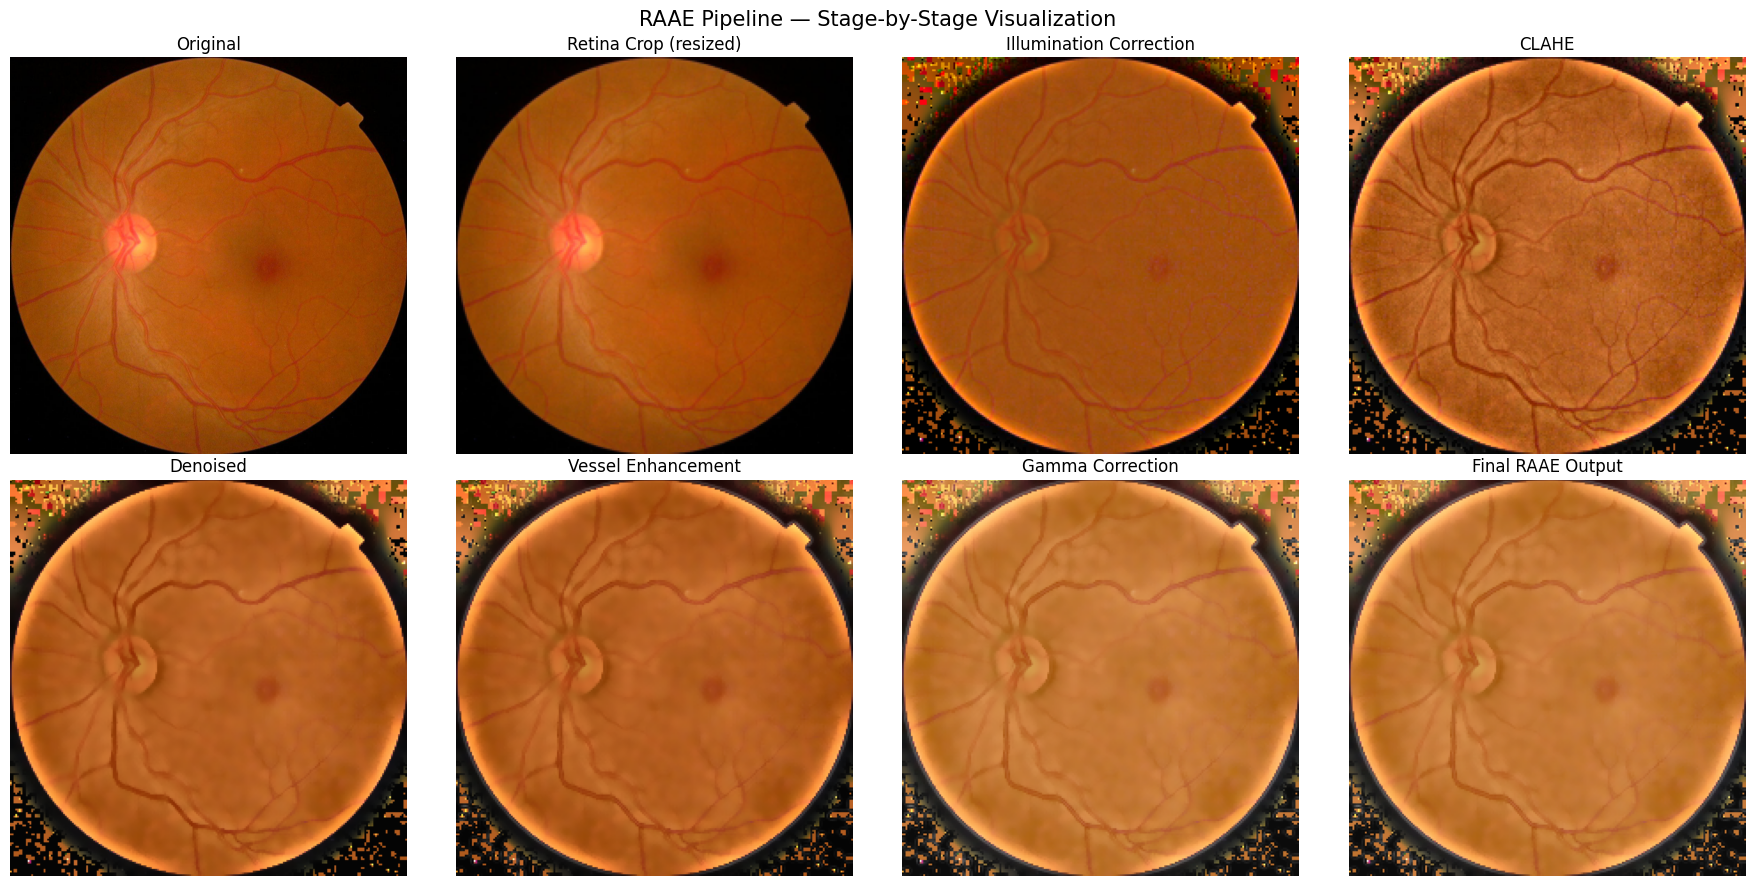

In [22]:
# ============================================================
# Find a sample image automatically
# ============================================================

from pathlib import Path

def find_one_sample_image(base_dir):
    """
    Recursively finds the first PNG/JPG image.
    Handles different Kaggle folder structures.
    """

    base_dir = Path(base_dir)

    files = list(base_dir.rglob("*.png")) + list(base_dir.rglob("*.jpg"))

    if not files:
        raise FileNotFoundError(
            f"No images found anywhere inside: {base_dir}"
        )

    return str(sorted(files)[0])


_demo_path = find_one_sample_image("/kaggle/input/datasets/mariaherrerot/aptos2019")

print("Using image:")
print(_demo_path)


_demo_bgr = cv2.imread(_demo_path)

assert _demo_bgr is not None, f"Could not read image: {_demo_path}"


_demo_result = raae_pipeline(
    _demo_bgr,
    target_size=TARGET_SIZE,
    verbose=True
)


stage_order = [
    ("original", "Original"),
    ("resized_early", "Retina Crop (resized)"),
    ("illumination_corrected", "Illumination Correction"),
    ("clahe", "CLAHE"),
    ("denoised", "Denoised"),
    ("vessel_enhanced", "Vessel Enhancement"),
    ("gamma_corrected", "Gamma Correction"),
    ("final_rgb", "Final RAAE Output"),
]


fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.ravel()

for ax, (key, title) in zip(axes, stage_order):

    img = _demo_result[key]

    if key == "final_rgb":
        ax.imshow(img)
    else:
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

    ax.set_title(title)
    ax.axis("off")


plt.suptitle(
    "RAAE Pipeline — Stage-by-Stage Visualization",
    fontsize=15
)

plt.tight_layout()
plt.show()

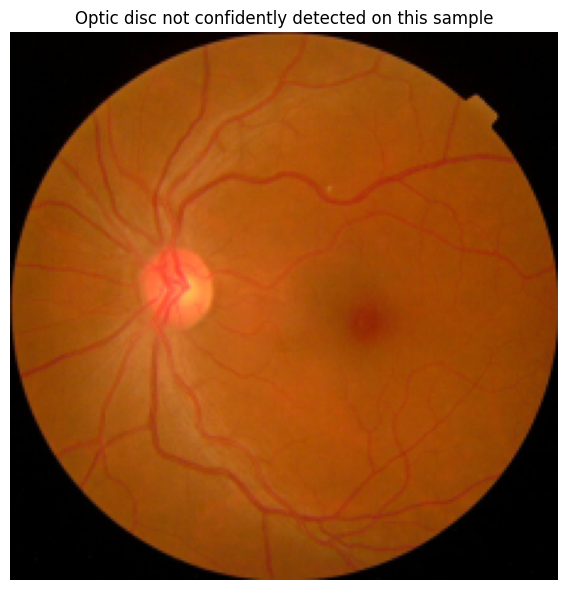

In [23]:
_overlay = cv2.cvtColor(_demo_result["resized_early"], cv2.COLOR_BGR2RGB).copy()
_landmarks = _demo_result["landmarks"]

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.imshow(_overlay)

if _landmarks is not None:
    dcx, dcy, dr = _landmarks["optic_disc"]
    mx, my = _landmarks["macula_estimate"]

    disc_circle = plt.Circle((dcx, dcy), dr, color="lime", fill=False, linewidth=2, label="Optic Disc")
    macula_circle = plt.Circle((mx, my), max(dr // 2, 15), color="red", fill=False, linewidth=2, label="Macula (estimated)")
    ax.add_patch(disc_circle)
    ax.add_patch(macula_circle)
    ax.legend(loc="upper right")
    ax.set_title("Optic Disc (green) & Macula Estimate (red)", fontsize=12)
else:
    ax.set_title("Optic disc not confidently detected on this sample", fontsize=12)

ax.axis("off")
plt.tight_layout()
plt.show()

  Retina bbox: (351, 0, 2712, 2136) | Gamma used: 0.605 | Disc/macula found: False
Output shape : (224, 224, 3)
Output dtype : uint8


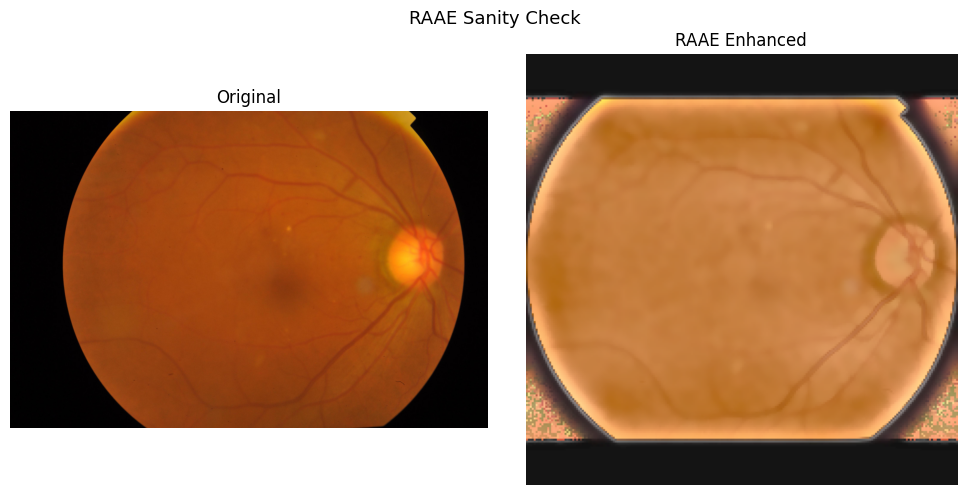

In [24]:
_sanity_path = find_one_sample_image(TRAIN_IMG_DIR)
_sanity_bgr = cv2.imread(_sanity_path)
assert _sanity_bgr is not None, f"Could not read sanity-check image: {_sanity_path}"

_sanity_result = raae_pipeline(_sanity_bgr, target_size=TARGET_SIZE, verbose=True)
_final = _sanity_result["final_rgb"]

print(f"Output shape : {_final.shape}")
print(f"Output dtype : {_final.dtype}")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(cv2.cvtColor(_sanity_bgr, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(_final)
axes[1].set_title("RAAE Enhanced")
axes[1].axis("off")

plt.suptitle("RAAE Sanity Check", fontsize=13)
plt.tight_layout()
plt.show()

In [25]:
train_image_files = list(Path(TRAIN_IMG_DIR).glob("*.png"))
print(f"Training images found: {len(train_image_files)}")

train_success = 0
train_failed = 0

for img_path in tqdm(train_image_files, desc="RAAE — train"):
    try:
        img = cv2.imread(str(img_path))
        if img is None:
            train_failed += 1
            continue

        result = raae_pipeline(img, target_size=TARGET_SIZE, verbose=False)
        enhanced_bgr = cv2.cvtColor(result["final_rgb"], cv2.COLOR_RGB2BGR)

        cv2.imwrite(os.path.join(RAAE_TRAIN_OUTPUT_DIR, img_path.name), enhanced_bgr)
        train_success += 1

    except Exception:
        train_failed += 1

print("==============================")
print("RAAE training-set generation complete")
print("Saved :", train_success)
print("Failed:", train_failed)
print("Output:", RAAE_TRAIN_OUTPUT_DIR)

Training images found: 2930


RAAE — train: 100%|██████████| 2930/2930 [15:40<00:00,  3.12it/s]

RAAE training-set generation complete
Saved : 2930
Failed: 0
Output: /kaggle/working/RAAE_train_images


In [26]:
valid_image_files = list(Path(VALID_IMG_DIR).glob("*.png"))
print(f"Validation images found: {len(valid_image_files)}")

valid_success = 0
valid_failed = 0

for img_path in tqdm(valid_image_files, desc="RAAE — valid"):
    try:
        img = cv2.imread(str(img_path))
        if img is None:
            valid_failed += 1
            continue

        result = raae_pipeline(img, target_size=TARGET_SIZE, verbose=False)
        enhanced_bgr = cv2.cvtColor(result["final_rgb"], cv2.COLOR_RGB2BGR)

        cv2.imwrite(os.path.join(RAAE_VALID_OUTPUT_DIR, img_path.name), enhanced_bgr)
        valid_success += 1

    except Exception:
        valid_failed += 1

print("==============================")
print("RAAE validation-set generation complete")
print("Saved :", valid_success)
print("Failed:", valid_failed)
print("Output:", RAAE_VALID_OUTPUT_DIR)

Validation images found: 366


RAAE — valid: 100%|██████████| 366/366 [02:00<00:00,  3.05it/s]

RAAE validation-set generation complete
Saved : 366
Failed: 0
Output: /kaggle/working/RAAE_valid_images


In [27]:
print("=" * 50)
print("RAAE PREPROCESSING — FINAL SUMMARY")
print("=" * 50)

print("\nTraining set")
print(f"  Processed : {train_success}")
print(f"  Failed    : {train_failed}")
print(f"  Output dir: {RAAE_TRAIN_OUTPUT_DIR}")

print("\nValidation set")
print(f"  Processed : {valid_success}")
print(f"  Failed    : {valid_failed}")
print(f"  Output dir: {RAAE_VALID_OUTPUT_DIR}")

print("\nNext step: run Swin_RAAE_Training.ipynb, pointing its Dataset class at "
      "RAAE_TRAIN_OUTPUT_DIR / RAAE_VALID_OUTPUT_DIR instead of the raw APTOS directories.")

RAAE PREPROCESSING — FINAL SUMMARY

Training set
  Processed : 2930
  Failed    : 0
  Output dir: /kaggle/working/RAAE_train_images

Validation set
  Processed : 366
  Failed    : 0
  Output dir: /kaggle/working/RAAE_valid_images

Next step: run Swin_RAAE_Training.ipynb, pointing its Dataset class at RAAE_TRAIN_OUTPUT_DIR / RAAE_VALID_OUTPUT_DIR instead of the raw APTOS directories.
